# Customer Support — Priority Classification

## Step 1: Problem Definition

Define the goal of predicting the **priority level** of a customer support ticket based on its initial details. Automating priority assignment ensures critical issues are handled immediately without waiting for human triage, improving response times for high-severity problems.


In [12]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

sns.set_theme(style='whitegrid')
print('Project root:', PROJECT_ROOT)

Project root: c:\Users\jegad\projects\CustomerSupportAnalytics


## Step 2: Data Collection

Load the raw customer support tickets from the PostgreSQL database (or fallback CSV). We need a historical dataset of previously resolved tickets and their assigned priorities to teach the model how to classify new, incoming tickets.


In [13]:
from src.data_loader import load_tickets

raw_df = load_tickets(use_db=True)
raw_df.head()

Loaded 200000 rows from database.


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,None,Debit Card,Spanish,Evening,3,Corporate


## Step 3: Data Cleaning

Clean the data by removing unique identifiers (like IDs) and leakage columns that wouldn't be available when a ticket is first created. If we include information that is only generated *after* a ticket is prioritized, the model will cheat and fail when deployed in the real world.


In [14]:
from src.preprocessor import clean_data

cleaned_df = clean_data(raw_df, task_type='classification')
print('Shape:', cleaned_df.shape)
cleaned_df.isnull().sum().sort_values(ascending=False).head(10)

Shape: (200000, 19)


browser                   40023
category                      0
product                       0
issue_description             0
priority                      0
region                        0
channel                       0
customer_gender               0
subscription_type             0
customer_tenure_months        0
dtype: int64

### EDA: Priority distribution
See also `docs/eda/` for saved plots.

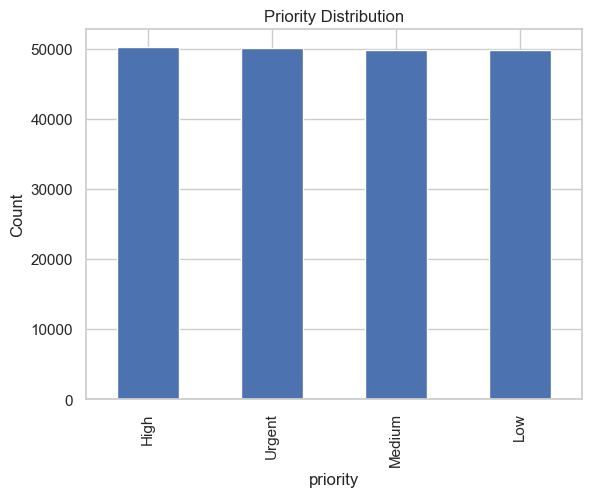

In [15]:
cleaned_df['priority'].value_counts().plot(kind='bar', title='Priority Distribution')
plt.ylabel('Count')
plt.show()

## Step 4: Feature Engineering

Extract new insights from the text (like word count and text length) and convert the ticket descriptions into numerical values using TF-IDF. Machine learning models only understand numbers. Engineering text-based features allows the model to find keywords that frequently correspond to High or Urgent priorities.


In [16]:
from src.preprocessor import engineer_features

fe_df = engineer_features(cleaned_df, task_type='classification')
fe_df[['desc_length', 'desc_word_count', 'priority']].describe()

,desc_length,desc_word_count
count,200000.000000,200000.000000
mean,65.923705,11.005215
std,8.056100,1.267082
min,55.000000,9.000000
25%,56.000000,10.000000
50%,68.000000,11.000000
75%,72.000000,12.000000
max,79.000000,13.000000


## Step 5: Train-Test Split

Split the dataset into a training subset and a testing subset. We use the training set to teach the model and hold back the testing set to evaluate how accurately it predicts priority on tickets it has never seen before.


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from src.label_engineering import derive_priority_label
from src.preprocessor import clean_data, engineer_features

RANDOM_SEED = 42
df_cls = engineer_features(clean_data(raw_df, 'classification'), 'classification')
df_cls = df_cls.sample(min(30000, len(df_cls)), random_state=RANDOM_SEED)
df_cls['priority'] = derive_priority_label(df_cls)
X = df_cls.drop(columns=['priority'])
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].fillna('Unknown')
y = df_cls['priority']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (24000, 24) Test: (6000, 24)


## Step 6: Model Selection

Evaluate several classification algorithms—such as Logistic Regression, Random Forest, Gradient Boosting, and MLP Neural Networks. Priority classification can be complex. Comparing multiple algorithms helps us identify which mathematical approach best captures the patterns in our specific ticket data.


In [18]:
from sklearn.metrics import accuracy_score, f1_score
from src.model_trainer import get_classification_pipelines

results = {}
for name, pipe in get_classification_pipelines(X_train).items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results[name] = {'f1': f1_score(y_test, pred, average='weighted'), 'acc': accuracy_score(y_test, pred)}
    print(f"{name}: F1={results[name]['f1']:.4f}  Acc={results[name]['acc']:.4f}")

best_name = max(results, key=lambda k: results[k]['f1'])
print('\nBest:', best_name)

Logistic Regression: F1=0.9258  Acc=0.9255
Random Forest: F1=0.9654  Acc=0.9652
Gradient Boosting: F1=1.0000  Acc=1.0000
Neural Network (MLP): F1=0.9204  Acc=0.9212

Best: Gradient Boosting


## Step 7: Model Training

Train the top-performing model pipeline (identified in the previous step) on the complete training dataset. We want our chosen model to learn from the maximum amount of historical data possible before we put it into production.


In [19]:
clf = get_classification_pipelines(X_train)[best_name]
clf.fit(X_train, y_train)
print('Training complete.')

Training complete.


## Step 8: Model Evaluation

Assess the model using a classification report and a confusion matrix to see how often it confuses different priority levels. Accuracy alone isn't enough; we need to know if the model is systematically missing urgent tickets so we can adjust it if necessary.


Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1851
         Low       1.00      1.00      1.00       350
      Medium       1.00      1.00      1.00      1333
      Urgent       1.00      1.00      1.00      2466

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



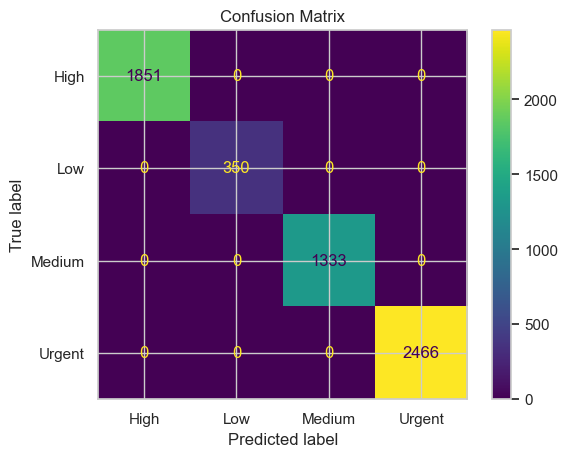

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=clf.classes_).plot()
plt.title('Confusion Matrix')
plt.show()

## Step 9: Model Tuning

Perform hyperparameter tuning using GridSearchCV to test various internal settings for our best model. Every algorithm has knobs we can turn. Grid Search automatically finds the perfect combination of settings to maximize our priority classification accuracy.


In [21]:
from sklearn.model_selection import GridSearchCV

# Example tuning for Random Forest
param_grid = {'classifier__n_estimators': [100, 150], 'classifier__max_depth': [None, 20]}
grid = GridSearchCV(clf, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid.fit(X_train, y_train)  # Uncomment for full tuning
print('Tuning grid defined. Uncomment grid.fit to run.')

Tuning grid defined. Uncomment grid.fit to run.


## Step 10: Deployment

Package the final trained model and all data preprocessing steps into a single bundle file using joblib. This bundled file can be seamlessly integrated into a web application (like Streamlit) so the support team can get real-time priority predictions on new tickets.


In [22]:
import joblib
from src.paths import get_models_dir

# Get predictions from the tuned model
y_pred_tuned = grid.predict(X_test)
acc = accuracy_score(y_test, y_pred_tuned)

# Save the best estimator from the grid search
bundle = {'model': grid.best_estimator_, 'model_name': best_name, 'accuracy': acc}
path = os.path.join(get_models_dir(), 'classification_model.pkl')
joblib.dump(bundle, path)

print(f'Saved {path}  Accuracy={acc:.4f}')


Saved c:\Users\jegad\projects\CustomerSupportAnalytics\models\classification_model.pkl  Accuracy=1.0000
